In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, ConfusionMatrixDisplay, classification_report

In [2]:
df = pd.read_csv("Public_Bus_Operations_Multi_Target.csv")

In [3]:
df.head()

,trip_id,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes
0,TRIP201396,Windy,Mini Bus,Moderate,13.00,9,23.0,7.91,7,Moderate Delay,53.84
1,TRIP203651,Rainy,Standard,High,4.19,3,26.0,4.03,5,Moderate Delay,40.26
2,TRIP200153,Rainy,Standard,Moderate,4.42,5,26.0,3.90,6,On Time,28.64
3,TRIP209009,Rainy,NaN,Moderate,21.29,19,31.0,4.85,22,Severe Delay,112.70
4,TRIP204405,Clear,Standard,Low,12.37,15,39.0,3.02,20,On Time,47.37


In [4]:
df.shape

(10000, 11)

Number of Rows: 10000. <br>
Number of Columns: 11. <br>
each row represents one historical bus trip.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  10000 non-null  object 
 1   weather_condition        9742 non-null   object 
 2   bus_type                 9798 non-null   object 
 3   traffic_level            10000 non-null  object 
 4   route_distance_km        9849 non-null   float64
 5   stops_count              10000 non-null  int64  
 6   passenger_count          9818 non-null   float64
 7   driver_experience_years  9777 non-null   float64
 8   scheduled_start_hour     10000 non-null  int64  
 9   delay_level              10000 non-null  object 
 10  trip_duration_minutes    10000 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 859.5+ KB


In [6]:
df.describe()

,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,trip_duration_minutes
count,9849.000000,10000.000000,9818.000000,9777.000000,10000.000000,10000.000000
mean,10.622125,11.227500,30.434101,6.151693,13.957900,60.837522
std,5.489059,6.064505,12.695660,3.999918,5.501323,33.956659
min,2.000000,3.000000,3.000000,0.200000,5.000000,12.000000
25%,6.530000,7.000000,21.000000,3.140000,9.000000,36.660000
50%,9.600000,10.000000,31.000000,5.280000,14.000000,52.335000
75%,13.660000,15.000000,39.000000,8.270000,19.000000,76.490000
max,32.000000,37.000000,65.000000,18.000000,23.000000,180.000000


In [7]:
df.describe(include="O")

,trip_id,weather_condition,bus_type,traffic_level,delay_level
count,10000,9742,9798,10000,10000
unique,9850,4,3,4,3
top,TRIP204870,Clear,Standard,Moderate,On Time
freq,2,5305,5594,3785,3334


In [8]:
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

                         Missing Count  Missing %
weather_condition                  258       2.58
bus_type                           202       2.02
route_distance_km                  151       1.51
passenger_count                    182       1.82
driver_experience_years            223       2.23


In [9]:
df.duplicated().sum()

np.int64(150)

quality problems: <br>
150 duplicated rows. <br>
missing values in 5 columns. <br>
missing values percentages are relatively small. <br>
there are no missing values in the two target variables. <br>
However, these problems will affect the models results.

In [10]:
classification_target_counts = df['delay_level'].value_counts()
target_pct = df['delay_level'].value_counts(normalize=True).round(4) * 100
print(pd.DataFrame({'Count': classification_target_counts, 'Percentage': target_pct.round(1)}))

                Count  Percentage
delay_level                      
On Time          3334        33.3
Moderate Delay   3333        33.3
Severe Delay     3333        33.3


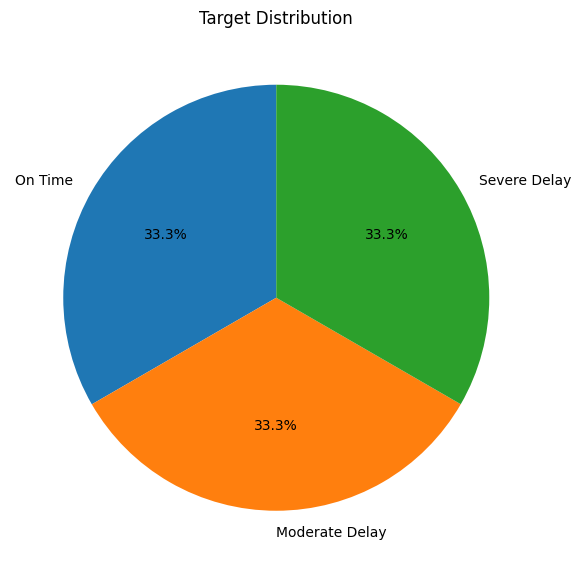

In [11]:
plt.figure(figsize=(6, 6))
plt.pie(classification_target_counts, labels=classification_target_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Target Distribution')
plt.tight_layout()
plt.show()

All the classes are balanced, so accuracy will provide a useful measure.

In [12]:
df["trip_duration_minutes"].describe()

count    10000.000000
mean        60.837522
std         33.956659
min         12.000000
25%         36.660000
50%         52.335000
75%         76.490000
max        180.000000
Name: trip_duration_minutes, dtype: float64

<Axes: xlabel='trip_duration_minutes', ylabel='Count'>

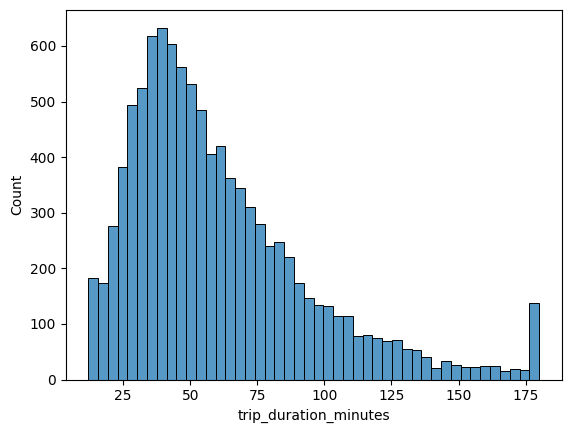

In [13]:
sns.histplot(data=df, x="trip_duration_minutes")

<Axes: xlabel='trip_duration_minutes'>

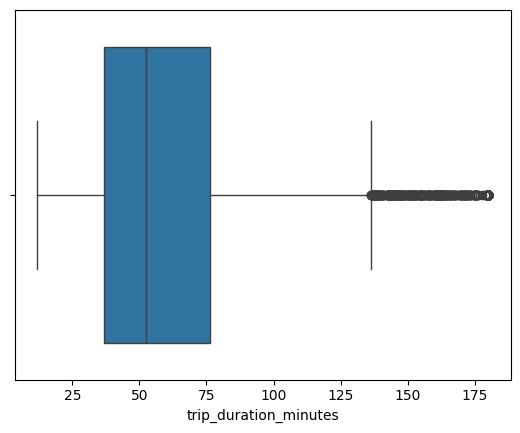

In [14]:
sns.boxplot(data=df, x="trip_duration_minutes")

The mean trip duration is approximately 60.84 minutes, while the median is approximately 52.34 minutes <br>
The median is a better describtion <br>
range: 12-180 minutes. <br>
trip_duration_minutes is right (positive) skewed. <br>
there are some extreme values from 135m-180m, especially at 180m, and this can cause prediction errors.
This indicates there are long trips.

### Numerical Features vs the Classification Target

Which numerical features affect the classification target ?

In [15]:
df['delay_level_flag'] = df['delay_level'].map({
    'On Time': 0,
    'Moderate Delay': 1,
    'Severe Delay': 2
})

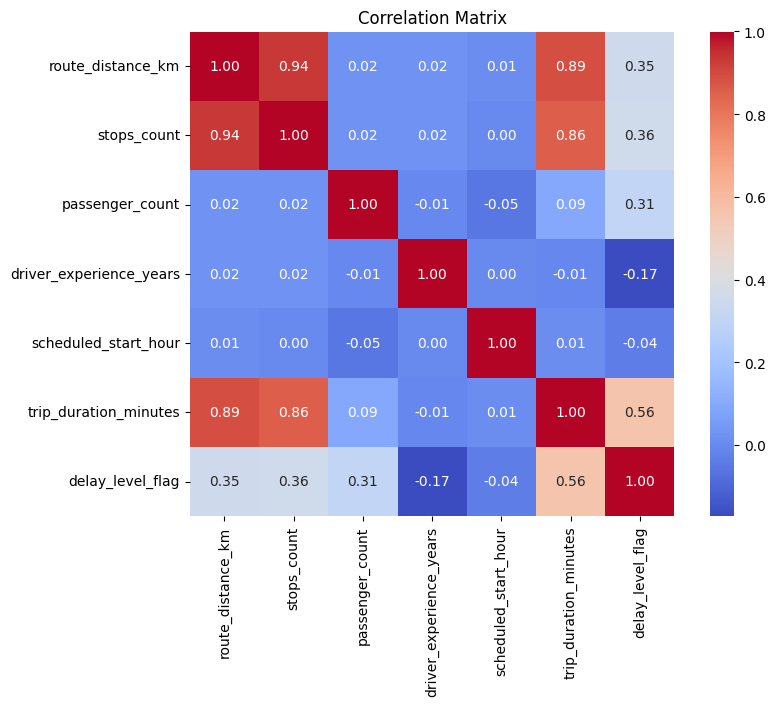

In [16]:
numeric_for_correlation = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(9, 7))

sns.heatmap(numeric_for_correlation, annot=True, fmt='.2f', square=True, cmap='coolwarm')
plt.tight_layout()
plt.title('Correlation Matrix')
plt.show()

trip duration minutes do affect delay level. <br>
and this is usual. <br>
Also route distance, stops count and passenger count affect it to an extent.

In [17]:
df.head()

,trip_id,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes,delay_level_flag
0,TRIP201396,Windy,Mini Bus,Moderate,13.00,9,23.0,7.91,7,Moderate Delay,53.84,1
1,TRIP203651,Rainy,Standard,High,4.19,3,26.0,4.03,5,Moderate Delay,40.26,1
2,TRIP200153,Rainy,Standard,Moderate,4.42,5,26.0,3.90,6,On Time,28.64,0
3,TRIP209009,Rainy,NaN,Moderate,21.29,19,31.0,4.85,22,Severe Delay,112.70,2
4,TRIP204405,Clear,Standard,Low,12.37,15,39.0,3.02,20,On Time,47.37,0


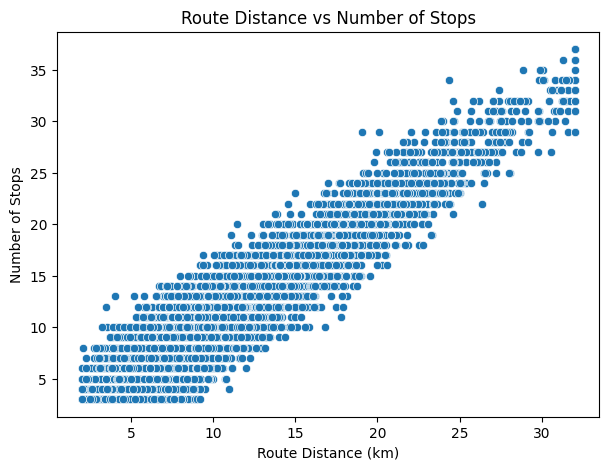

In [18]:
#Is route distance related to stops count ?

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="route_distance_km", y="stops_count")

plt.xlabel("Route Distance (km)")
plt.ylabel("Number of Stops")
plt.title("Route Distance vs Number of Stops")
plt.show()

As the route distance increases the number of stops increases. <br>
this means number of people get on and get down increases by increasing distance.

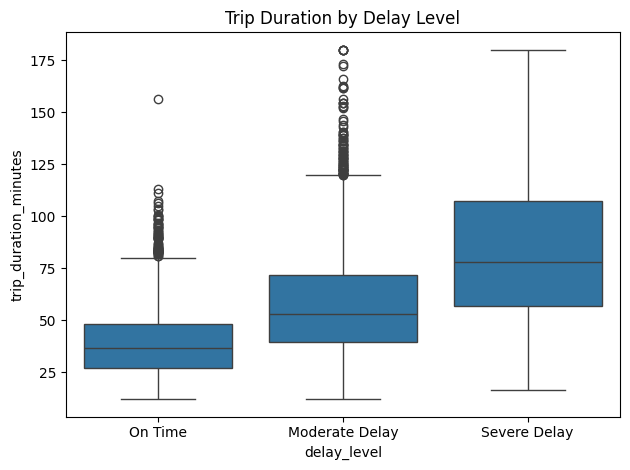

In [19]:
#Does trip duration differ across delay levels?

sns.boxplot(data=df, x='delay_level', y='trip_duration_minutes', order=['On Time', 'Moderate Delay', "Severe Delay"])
plt.title('Trip Duration by Delay Level')
plt.tight_layout()
plt.show()

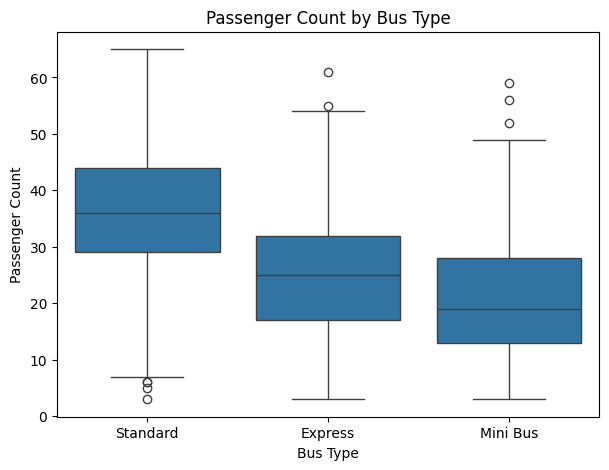

In [20]:
#Does passenger count vary across bus types?


plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="bus_type", y="passenger_count", order=["Standard", "Express", "Mini Bus"])
plt.xlabel("Bus Type")
plt.ylabel("Passenger Count")
plt.title("Passenger Count by Bus Type")
plt.show()

More pepople prefer Standard busses then express ones then mini busses

In [21]:
#dropping duplicates causing wrong predictions

clean_df = (df.drop_duplicates().drop(columns=['trip_id', 'delay_level_flag']).reset_index(drop=True))

Duplicates issue has been handled, but missing values issue has not. <br>
This is because missing values will be handled in simple imputer to avoid data lekage.

In [22]:
clean_df.shape

(9850, 10)

In [23]:
feature_columns = [
    'weather_condition',
    'bus_type',
    'traffic_level',
    'route_distance_km',
    'stops_count',
    'passenger_count',
    'driver_experience_years',
    'scheduled_start_hour'
]

X = clean_df[feature_columns]
y_delay = clean_df['delay_level']
y_duration = clean_df['trip_duration_minutes']

print(X.shape)
print(y_delay.shape)
print(y_duration.shape)

(9850, 8)
(9850,)
(9850,)


In [24]:
X_train, X_test, y_delay_train, y_delay_test, y_duration_train, y_duration_test = train_test_split(
    X,
    y_delay,
    y_duration,
    test_size=0.20,
    random_state=42,
    stratify=y_delay
)

print(X_train.shape, X_test.shape)
print(y_delay_train.shape, y_delay_test.shape)
print(y_duration_train.shape, y_duration_test.shape)

(7880, 8) (1970, 8)
(7880,) (1970,)
(7880,) (1970,)


In [25]:
clean_df.head()

,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes
0,Windy,Mini Bus,Moderate,13.00,9,23.0,7.91,7,Moderate Delay,53.84
1,Rainy,Standard,High,4.19,3,26.0,4.03,5,Moderate Delay,40.26
2,Rainy,Standard,Moderate,4.42,5,26.0,3.90,6,On Time,28.64
3,Rainy,NaN,Moderate,21.29,19,31.0,4.85,22,Severe Delay,112.70
4,Clear,Standard,Low,12.37,15,39.0,3.02,20,On Time,47.37


80/20 random train test split was used

In [26]:
nominal_features = ['weather_condition', 'bus_type']
ordinal_features = ['traffic_level']
numerical_features = ['route_distance_km', 'stops_count', 'passenger_count',
                    'driver_experience_years', 'scheduled_start_hour']

In [27]:
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

                         Missing Count  Missing %
weather_condition                  258       2.58
bus_type                           202       2.02
route_distance_km                  151       1.51
passenger_count                    182       1.82
driver_experience_years            223       2.23


In [28]:
classification_target_counts = y_delay.value_counts()
target_pct = y_delay.value_counts(normalize=True).round(4) * 100
display(pd.DataFrame({'Count': classification_target_counts, 'Percentage': target_pct.round(1)}))

,Count,Percentage
delay_level,,
Severe Delay,3289,33.4
Moderate Delay,3281,33.3
On Time,3280,33.3


In [29]:
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
])
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        ['Low', 'Moderate', 'High', 'Severe']
    ]))
])
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', nominal_pipeline, nominal_features),
        ('ordinal', ordinal_pipeline, ordinal_features),
        ('numerical', numerical_pipeline, numerical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

In [31]:
model_search_space_class = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=42),
        'parameters': {
            'model__C': [0.1, 1, 10],
            'model__class_weight': [None, 'balanced'],
        },
    },

    'SVM': {
        'model': SVC(random_state=42),
        'parameters': [
            {
                'model__kernel': ['linear'],
                'model__C': [0.1, 1, 10],
                'model__class_weight': [None, 'balanced'],
            },
            {
                'model__kernel': ['rbf'],
                'model__C': [1, 10],
                'model__gamma': ['scale', 0.1],
                'model__class_weight': [None, 'balanced'],
            },
        ],
    }
}

In [32]:
def run_gridsearch_class(X_train, y_train, preprocessor, model_search_space_class, random_state=42):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    search_results = {}
    rows = []
    for model_name, specification in model_search_space_class.items():
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', specification['model']),
        ])
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=specification['parameters'],
            scoring='f1_macro', cv=cv, n_jobs=-1,
            return_train_score=False
        )
        search.fit(X_train, y_train)
        search_results[model_name] = search
        best_index = search.best_index_

        rows.append({
            'Model': model_name,
            'Mean CV F1-macro': search.best_score_,
            'Std CV F1-macro':
                search.cv_results_['std_test_score'][best_index],
            'Best Hyperparameters': search.best_params_
        })
        
    comparison_df = (pd.DataFrame(rows)
                    .sort_values('Mean CV F1-macro', ascending=False)
                    .reset_index(drop=True))
    return comparison_df, search_results

In [33]:
model_comparison_class, search_results_class = run_gridsearch_class(
    X_train, y_delay_train, preprocessor, model_search_space_class)
model_comparison_class

,Model,Mean CV F1-macro,Std CV F1-macro,Best Hyperparameters
0,SVM,0.699122,0.010868,"{'model__C': 1, 'model__class_weight': 'balanc..."
1,Logistic Regression,0.675272,0.016777,"{'model__C': 1, 'model__class_weight': 'balanc..."


In [34]:
worst_model_name_class = model_comparison_class.loc[1, 'Model']
worst_cv_f1 = model_comparison_class.loc[1, 'Mean CV F1-macro']
worst_search_class = search_results_class[worst_model_name_class]
print(f"Best model: {worst_model_name_class}  |  CV F1: {worst_cv_f1:.4f}")
print(f"Params: {worst_search_class.best_params_}")

Best model: Logistic Regression  |  CV F1: 0.6753
Params: {'model__C': 1, 'model__class_weight': 'balanced'}


In [35]:
best_model_name_class = model_comparison_class.loc[0, 'Model']
best_cv_f1 = model_comparison_class.loc[0, 'Mean CV F1-macro']
best_search_class = search_results_class[best_model_name_class]
print(f"Best model: {best_model_name_class}  |  CV F1: {best_cv_f1:.4f}")
print(f"Params: {best_search_class.best_params_}")

Best model: SVM  |  CV F1: 0.6991
Params: {'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 0.1, 'model__kernel': 'rbf'}


                precision    recall  f1-score   support

       On Time       0.57      0.59      0.58       656
Moderate Delay       0.77      0.75      0.76       656
  Severe Delay       0.80      0.79      0.79       658

      accuracy                           0.71      1970
     macro avg       0.71      0.71      0.71      1970
  weighted avg       0.71      0.71      0.71      1970



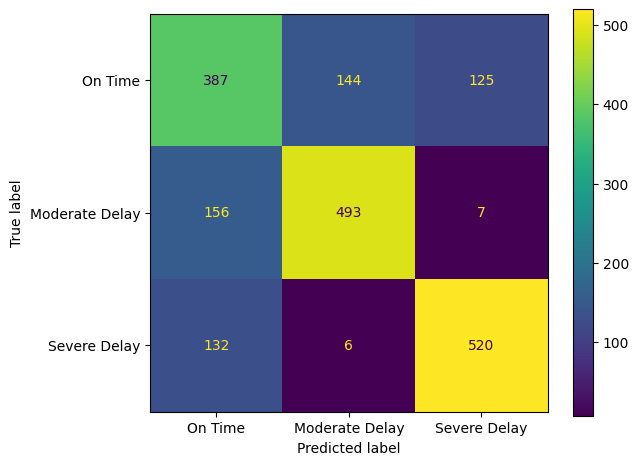

In [36]:
y_delay_pred_best = best_search_class.predict(X_test)

print(classification_report(
    y_delay_test,
    y_delay_pred_best,
    target_names=[
        'On Time',
        'Moderate Delay',
        'Severe Delay'
    ]
))

ConfusionMatrixDisplay.from_predictions(
    y_delay_test,
    y_delay_pred_best,
    display_labels=[
        'On Time',
        'Moderate Delay',
        'Severe Delay'
    ],
    values_format='d',
)

plt.tight_layout()
plt.show()

"On Time" is the worst class; it has the lowest precision and recall. <br>
Errors between "On Time" and "Moderate Delay" as they have more similarity. <br>
21% of "Severe Delay" predictions is wrong, so this may waste resources.

In [37]:
model_search_space_regg = {
    'Linear Regression': {
        'model': LinearRegression(),
        'parameters': {
            'model__fit_intercept': [True, False],
        },
    },

    'KNN Regressor': {
        'model': KNeighborsRegressor(),
        'parameters': [
            {
                'model__n_neighbors': [5, 9, 15],
                'model__weights': ['uniform', 'distance'],
                'model__p': [1, 2],
            },
        ],
    }
}

In [38]:
def run_gridsearch_regg(X_train, y_train, preprocessor, model_search_space_regg, random_state=42):
    cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    search_results = {}
    rows = []
    for model_name, specification in model_search_space_regg.items():
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', specification['model']),
        ])
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=specification['parameters'],
            scoring='r2', cv=cv, n_jobs=-1,
            return_train_score=False
        )
        search.fit(X_train, y_train)
        search_results[model_name] = search
        best_index = search.best_index_
        rows.append({
                    'Model': model_name,
                    'Mean CV R-squared': search.best_score_,
                    'Std CV R-squared': search.cv_results_['std_test_score'][best_index],
                    'Best Hyperparameters': search.best_params_,
})
    comparison_df = (pd.DataFrame(rows)
                    .sort_values('Mean CV R-squared', ascending=False)
                    .reset_index(drop=True))
    return comparison_df, search_results

In [39]:
model_comparison_regg, search_results_regg = run_gridsearch_regg(
    X_train, y_duration_train, preprocessor, model_search_space_regg)
model_comparison_regg

,Model,Mean CV R-squared,Std CV R-squared,Best Hyperparameters
0,KNN Regressor,0.926784,0.004159,"{'model__n_neighbors': 9, 'model__p': 1, 'mode..."
1,Linear Regression,0.924093,0.002990,{'model__fit_intercept': True}


In [40]:
best_model_name_regg = model_comparison_regg.loc[0, 'Model']
best_cv_r2 = model_comparison_regg.loc[0, 'Mean CV R-squared']
best_search_regg = search_results_regg[best_model_name_regg]

print(f"Best model: {best_model_name_regg}  |  CV R2: {best_cv_r2:.4f}")
print(f"Params: {best_search_regg.best_params_}")

Best model: KNN Regressor  |  CV R2: 0.9268
Params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}


In [41]:
y_duration_pred_best = best_search_regg.predict(X_test)

In [42]:
mae = mean_absolute_error(y_duration_test, y_duration_pred_best)
rmse = np.sqrt(mean_squared_error(y_duration_test, y_duration_pred_best))
r2 = r2_score(y_duration_test, y_duration_pred_best)

print(f"MAE:  {mae:.4f} minutes")
print(f"RMSE: {rmse:.4f} minutes")
print(f"R²:   {r2:.4f}")

MAE:  6.4882 minutes
RMSE: 8.6117 minutes
R²:   0.9364


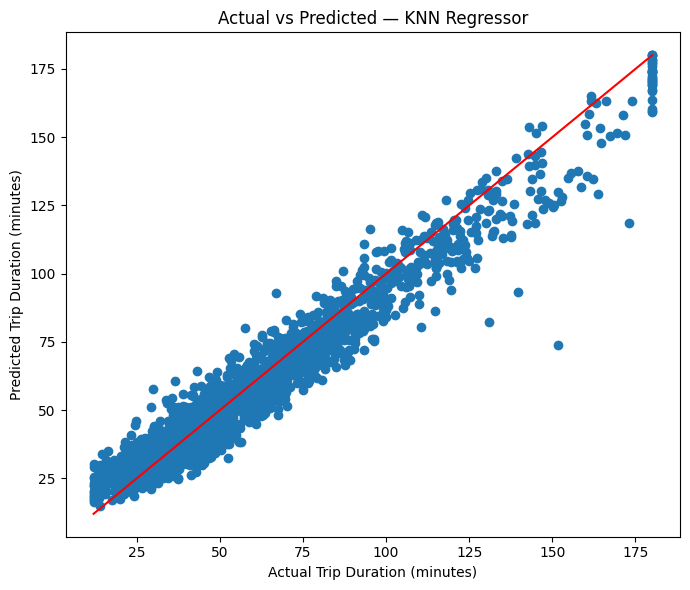

In [43]:
plt.figure(figsize=(7, 6))

plt.scatter(y_duration_test, y_duration_pred_best)

min_value = min(y_duration_test.min(), y_duration_pred_best.min())
max_value = max(y_duration_test.max(), y_duration_pred_best.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color='red'
)

plt.xlabel('Actual Trip Duration (minutes)')
plt.ylabel('Predicted Trip Duration (minutes)')
plt.title(f'Actual vs Predicted — {best_model_name_regg}')

plt.tight_layout()
plt.show()

Most predictions are relatively close to the diagonal line. <br>
The model tends to overpredict shorter trips and underpredict longer trips (150-180 m). <br>
This suggests that the KNN model performs well overall with an R2 of 0.936 but is less effective at extreme trips.

In [44]:
student_id = "EYOUTH-31002101601472" 

In [45]:
classification_path = f'{student_id}_best_bus_delay_classifier.joblib'
joblib.dump(best_search_class.best_estimator_, classification_path)

['EYOUTH-31002101601472_best_bus_delay_classifier.joblib']

In [46]:
regression_path = f'{student_id}_best_bus_duration_regressor.joblib'
joblib.dump(best_search_regg.best_estimator_, regression_path)

['EYOUTH-31002101601472_best_bus_duration_regressor.joblib']

In [47]:
loaded_classifier = joblib.load(classification_path)
loaded_regressor = joblib.load(regression_path)

In [48]:
df_new_trips = pd.read_csv("New_Bus_Trips.csv")

In [49]:
df_new_trips

,trip_id,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour
0,NEW001,Clear,Express,Low,5.8,6,18,12.0,10
1,NEW002,Rainy,Standard,High,14.5,16,40,4.5,18
2,NEW003,Foggy,Mini Bus,Severe,24.0,27,58,2.5,7
3,NEW004,Windy,Standard,Moderate,9.2,10,32,7.0,14
4,NEW005,Clear,Mini Bus,High,12.8,14,48,3.2,8
5,NEW006,Rainy,Express,Severe,21.5,23,52,6.5,17
6,NEW007,Clear,Standard,Low,3.5,4,12,15.0,6
7,NEW008,Foggy,Express,Moderate,17.2,18,35,9.0,20
8,NEW009,Windy,Mini Bus,High,8.7,9,44,1.5,22
9,NEW010,Rainy,Standard,Moderate,28.0,31,60,5.0,12


In [50]:
X_new = df_new_trips.drop(columns=['trip_id'])

In [51]:
df_new_trips['predicted_delay_level'] = loaded_classifier.predict(X_new)
df_new_trips['predicted_trip_duration_minutes'] = loaded_regressor.predict(X_new)

In [52]:
prediction_table = df_new_trips[['trip_id', 'predicted_delay_level', 'predicted_trip_duration_minutes']]
print(prediction_table)

  trip_id predicted_delay_level  predicted_trip_duration_minutes
0  NEW001               On Time                        19.163966
1  NEW002          Severe Delay                       100.750380
2  NEW003          Severe Delay                       171.375926
3  NEW004               On Time                        45.836484
4  NEW005          Severe Delay                        67.998976
5  NEW006          Severe Delay                       165.380225
6  NEW007               On Time                        19.907289
7  NEW008        Moderate Delay                        85.756454
8  NEW009          Severe Delay                        62.508440
9  NEW010          Severe Delay                       163.384532


In [53]:
prediction_table.to_csv("Final_Trip_Predictions.csv", index=False)